<a href="https://colab.research.google.com/github/Bamboohoccode/LLMs_From_Scratch/blob/main/Chapter_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

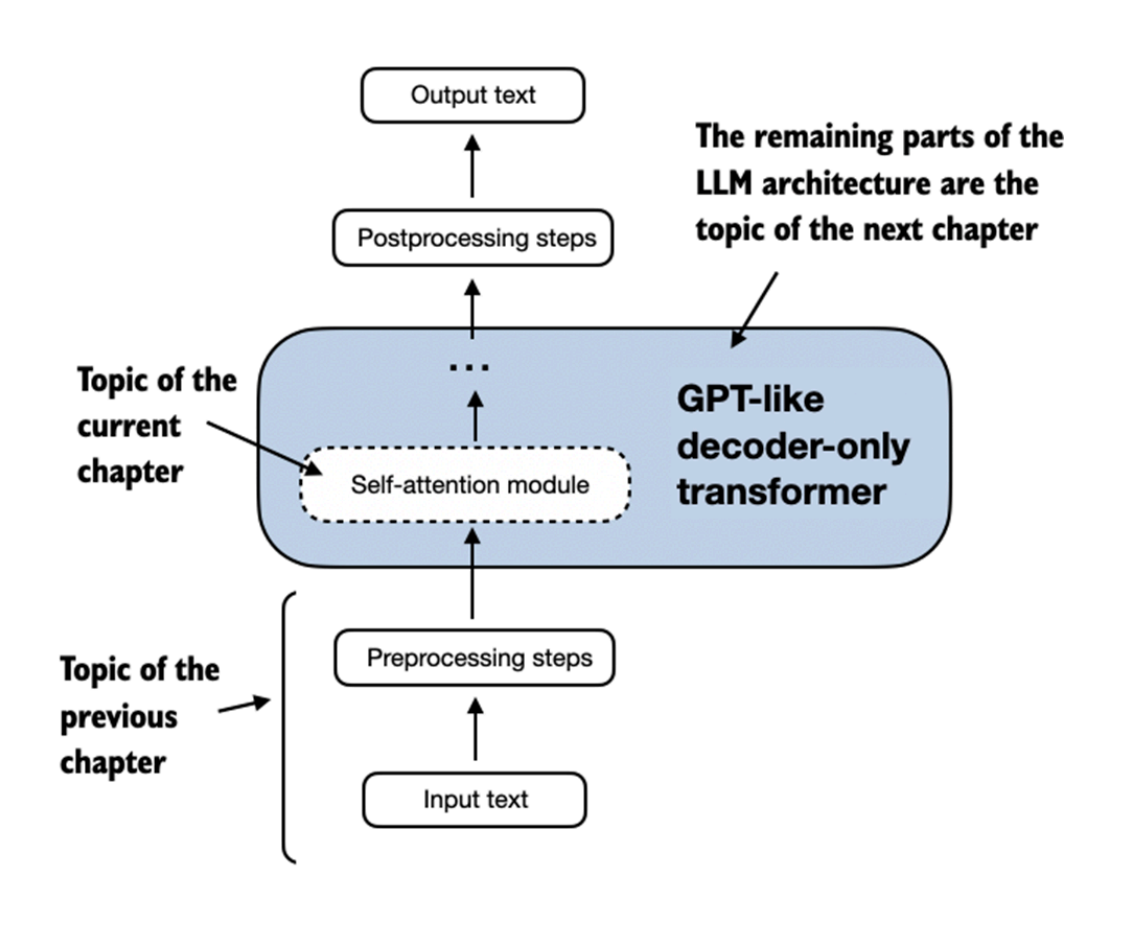

# we implement a simplified self-attention mechanism to compute these weights and the resulting context vector one step at a time

Ta xem đây là input đã được embedding.

In [1]:
import torch
inputs = torch.tensor(
[[0.43, 0.15, 0.89], # Your (x^1)
[0.55, 0.87, 0.66], # journey (x^2)
[0.57, 0.85, 0.64], # starts (x^3)
[0.22, 0.58, 0.33], # with (x^4)
[0.77, 0.25, 0.10], # one (x^5)
[0.05, 0.80, 0.55]] # step (x^6)
)

 the computation of the context vector z
(2) using the
second input element, x
(2) as a query

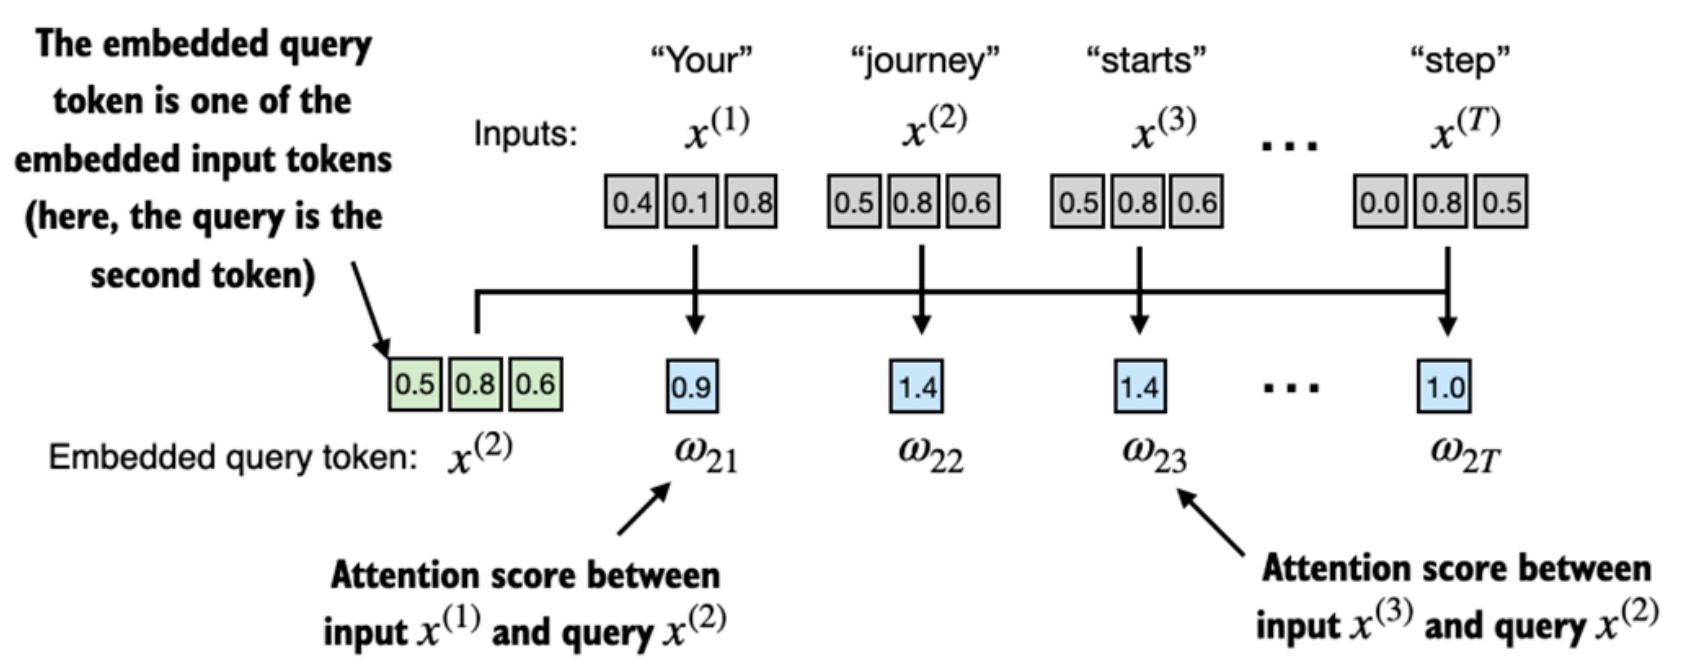

In [2]:
query = inputs[1]
attn_scores_2 = torch.empty(inputs.shape[0])
for i,x_i in enumerate(inputs):
    attn_scores_2[i] = x_i @ query
print(attn_scores_2)

tensor([0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865])


the next step is
to obtain the attention weights α21
to α2T by normalizing the attention scores.


In [3]:
attn_weights_2 = attn_scores_2 / attn_scores_2.sum()
attn_weights_2

tensor([0.1455, 0.2278, 0.2249, 0.1285, 0.1077, 0.1656])

But it's more common to use softmax function.

In [4]:
def softmax(attn_scores):
    return torch.exp(attn_scores) / torch.exp(attn_scores).sum()
attn_weights_2 = softmax(attn_scores_2)
attn_weights_2

tensor([0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581])

calculating the context vector z
(2) by multiplying the embedded
input tokens

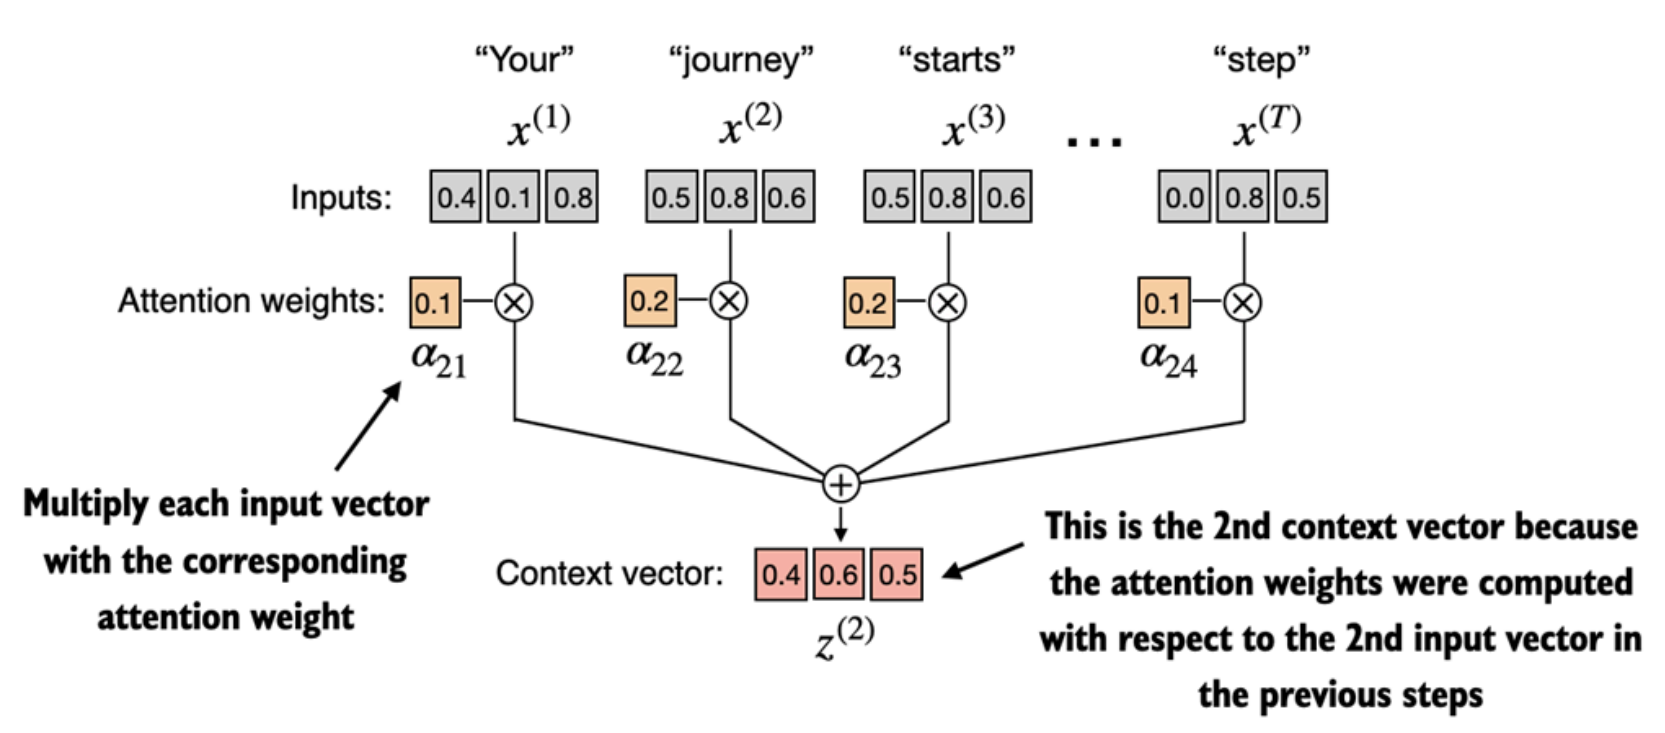

In [5]:
context_vec_2 = torch.zeros(inputs.shape[1])
for i,x_i in enumerate(inputs):
    context_vec_2 += x_i * attn_weights_2[i]
context_vec_2

tensor([0.4419, 0.6515, 0.5683])

# 3.3.2 Computing attention weights for all input tokens

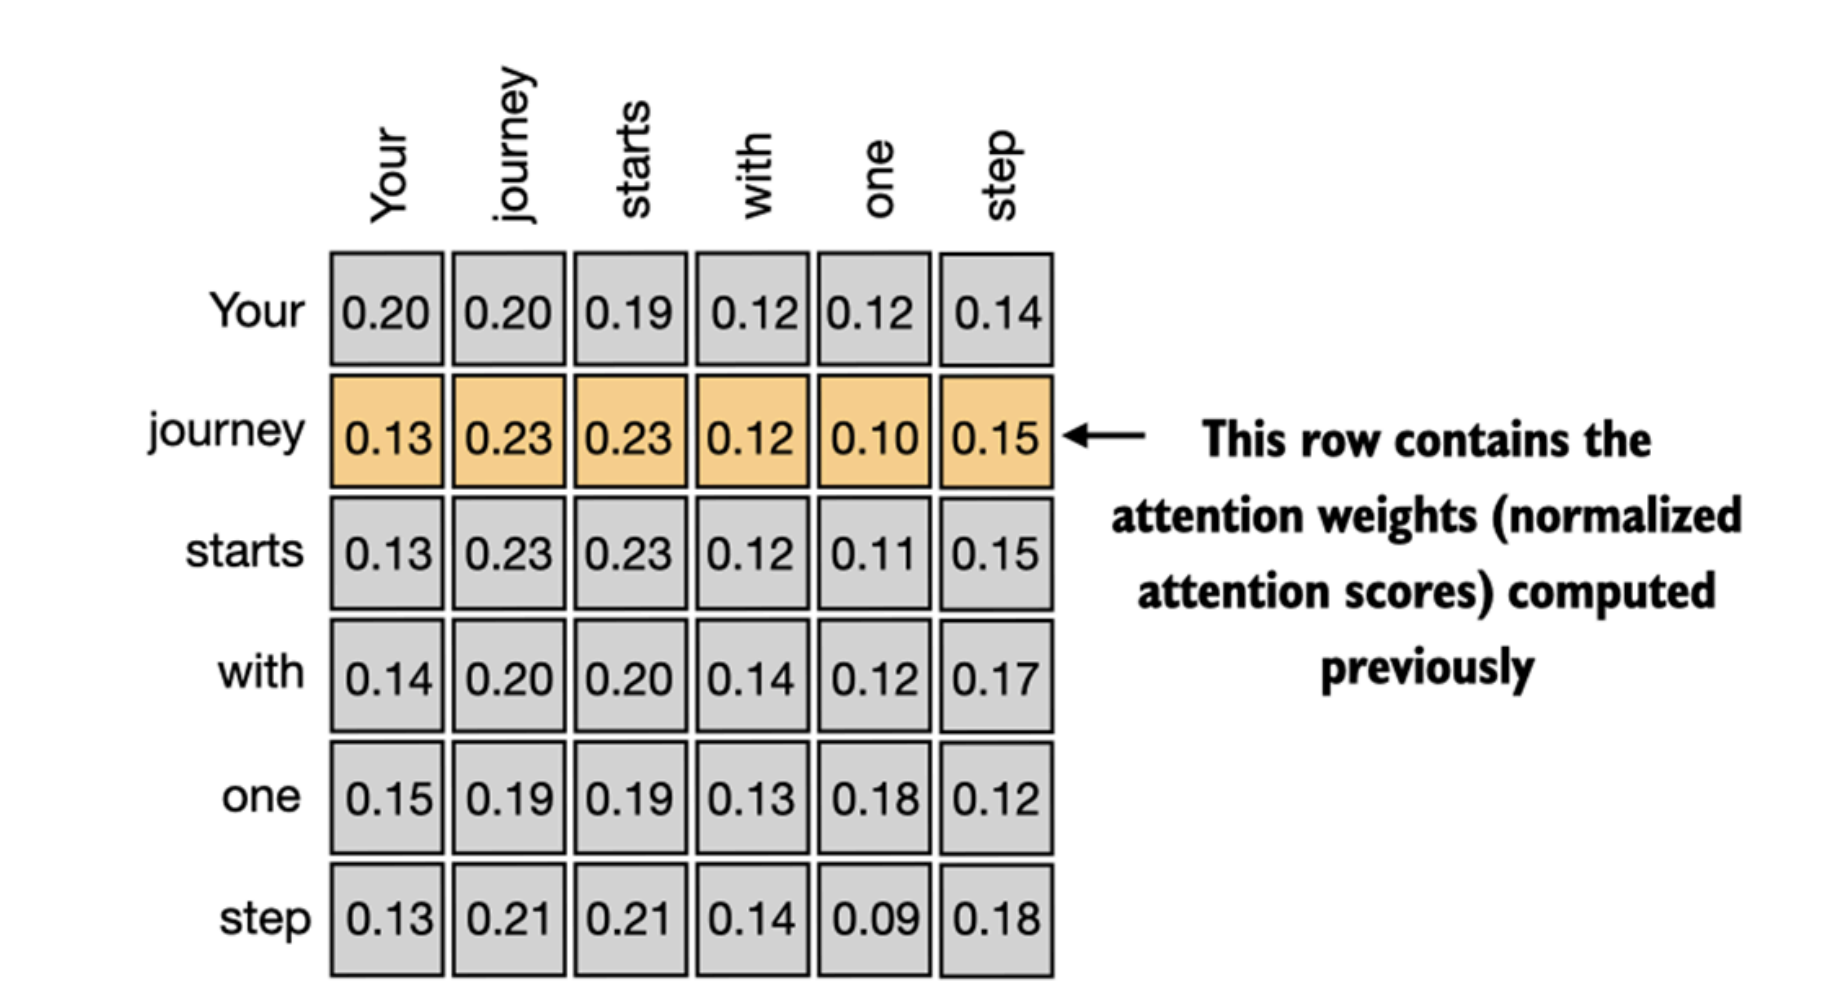

**3 Bước quan trọng**

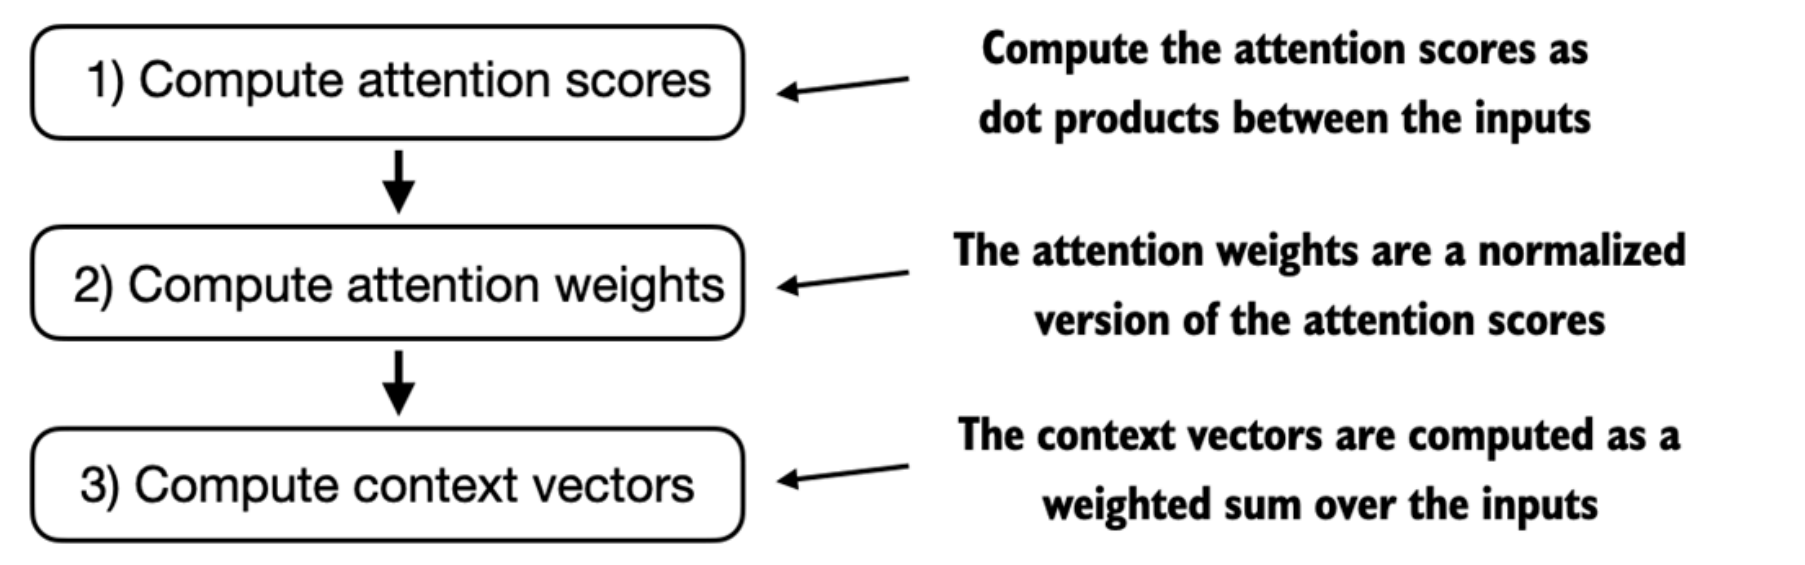

Bây giờ sẽ tính toán cho tất cả từ nhé.

In [6]:
attn_scores = inputs @ inputs.T
attn_scores

tensor([[0.9995, 0.9544, 0.9422, 0.4753, 0.4576, 0.6310],
        [0.9544, 1.4950, 1.4754, 0.8434, 0.7070, 1.0865],
        [0.9422, 1.4754, 1.4570, 0.8296, 0.7154, 1.0605],
        [0.4753, 0.8434, 0.8296, 0.4937, 0.3474, 0.6565],
        [0.4576, 0.7070, 0.7154, 0.3474, 0.6654, 0.2935],
        [0.6310, 1.0865, 1.0605, 0.6565, 0.2935, 0.9450]])

In [7]:
attn_weights = torch.softmax(attn_scores,dim = 1)
attn_weights

tensor([[0.2098, 0.2006, 0.1981, 0.1242, 0.1220, 0.1452],
        [0.1385, 0.2379, 0.2333, 0.1240, 0.1082, 0.1581],
        [0.1390, 0.2369, 0.2326, 0.1242, 0.1108, 0.1565],
        [0.1435, 0.2074, 0.2046, 0.1462, 0.1263, 0.1720],
        [0.1526, 0.1958, 0.1975, 0.1367, 0.1879, 0.1295],
        [0.1385, 0.2184, 0.2128, 0.1420, 0.0988, 0.1896]])

In [8]:
context_vec = attn_weights @ inputs
context_vec

tensor([[0.4421, 0.5931, 0.5790],
        [0.4419, 0.6515, 0.5683],
        [0.4431, 0.6496, 0.5671],
        [0.4304, 0.6298, 0.5510],
        [0.4671, 0.5910, 0.5266],
        [0.4177, 0.6503, 0.5645]])

#3.4 Implementing self-attention with trainable weights
This self attention mechanism is also called scaled dot-product attention

With every input, we also use same matrix Wk,Wq,Wv to give the corresponding vector

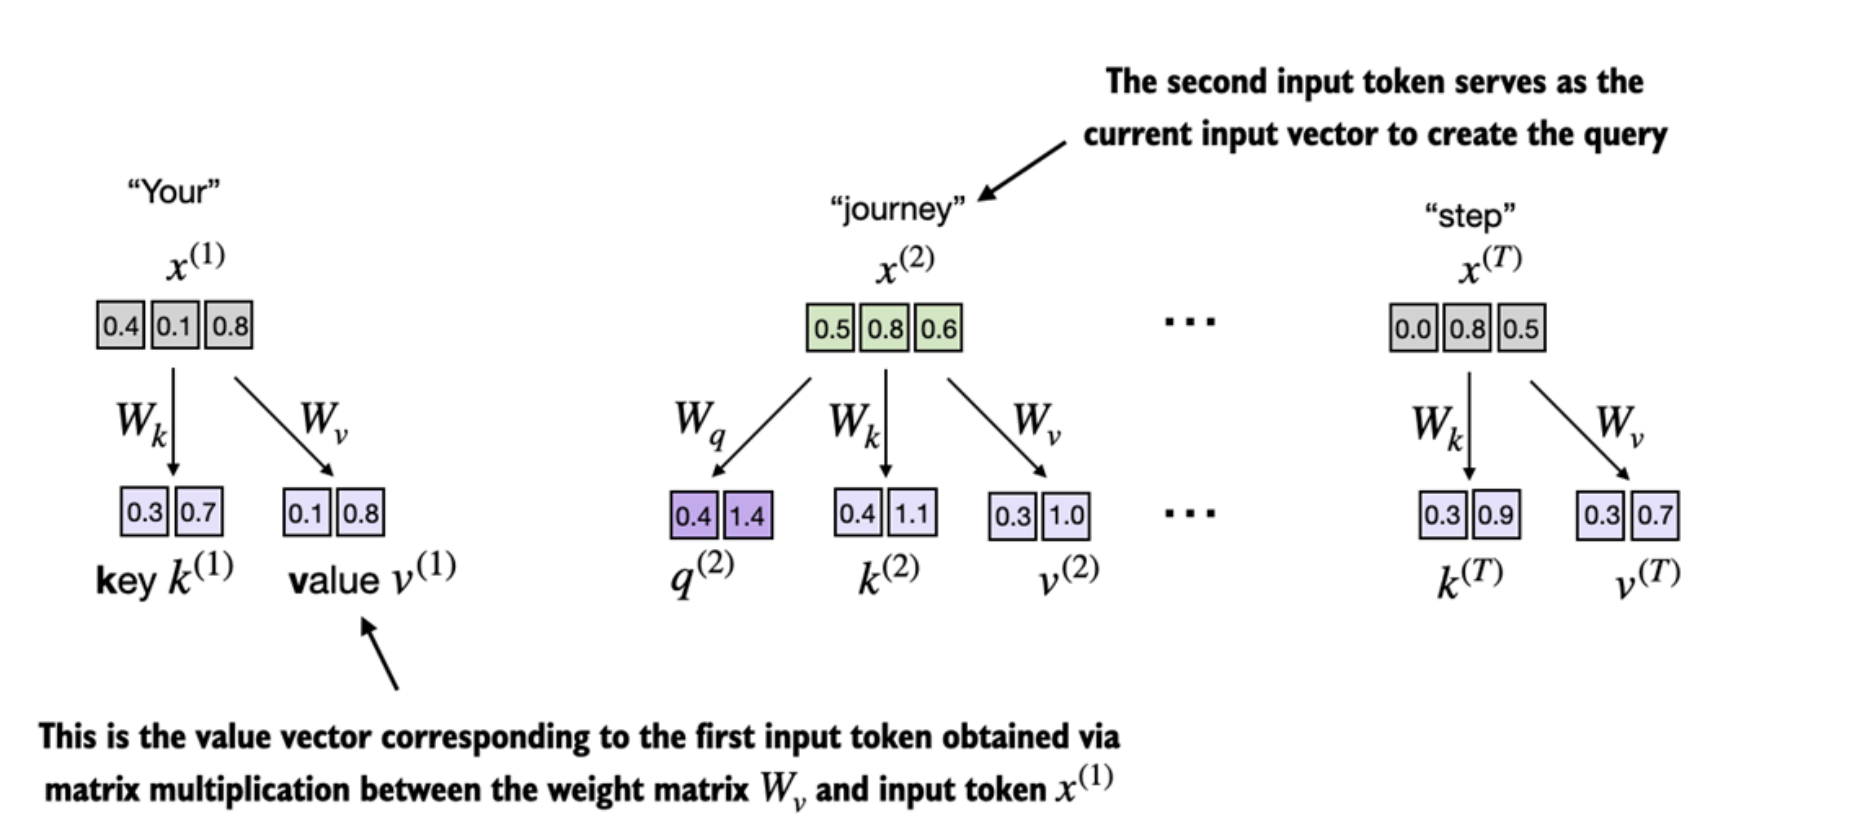

- A The second input element
- B The input embedding size, d=3
- C The output embedding size, d_out=2


In [9]:
x_2 = inputs[1] #A
d_in = inputs.shape[1] #B
d_out = 2 #C

Tiếp theo ta khởi tạo ma trận

In [10]:
W_q = torch.nn.Parameter(torch.rand(d_in,d_out))
W_k = torch.nn.Parameter(torch.rand(d_in,d_out))
W_v = torch.nn.Parameter(torch.rand(d_in,d_out))


In [11]:
keys =  inputs @ W_k
queries = inputs @ W_q
values = inputs @ W_v

In [12]:
query_2 = queries[1]
key_2 = keys[1]
attn_scores_22 =   query_2.dot(key_2)
print(attn_scores_22)

tensor(1.4565, grad_fn=<DotBackward0>)


In [13]:
attn_scores_2 = query_2 @ keys.T
attn_scores_2

tensor([1.1757, 1.4565, 1.4671, 0.6978, 1.2445, 0.6535],
       grad_fn=<SqueezeBackward4>)

In [14]:
d_k = keys.shape[1]
attn_weights_2 = torch.softmax(attn_scores_2 / d_k **0.5,dim = -1)
attn_weights_2

tensor([0.1694, 0.2066, 0.2082, 0.1208, 0.1779, 0.1171],
       grad_fn=<SoftmaxBackward0>)

In [15]:
context_vec_2 = attn_weights_2 @ values
context_vec_2

tensor([0.6701, 1.4842], grad_fn=<SqueezeBackward4>)

Tổng hợp cách tính.

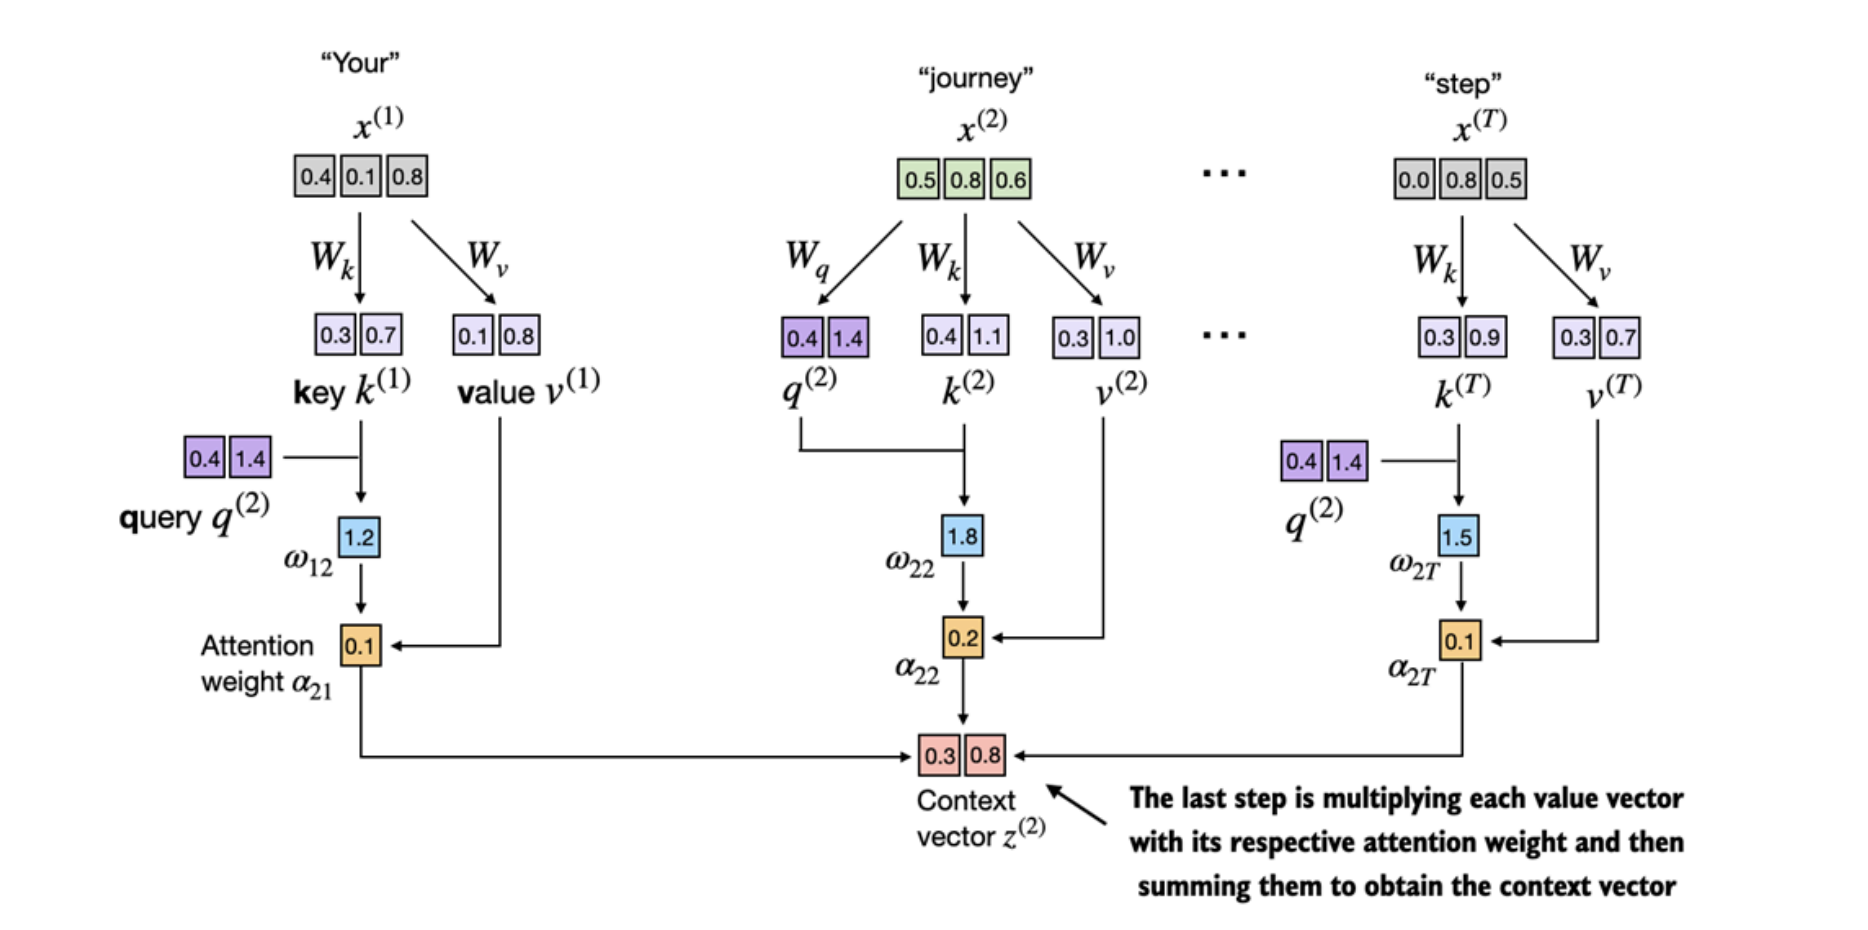

#3.4.2 Implementing a compact self-attention Python class


In [16]:
import torch.nn as nn
class SelfAttention_v1(nn.Module):
    def __init__(self,d_in,d_out):
        super().__init__()
        self.W_q = nn.Parameter(torch.rand(d_in,d_out))
        self.W_k = nn.Parameter(torch.rand(d_in,d_out))
        self.W_v = nn.Parameter(torch.rand(d_in,d_out))
    def forward(self,X):
        queries = X @ self.W_q
        keys = X @ self.W_k
        values = X @ self.W_v
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / queries.shape[1]**0.5,axis = -1)
        context_vec =  attn_weights @ values
        return context_vec


In [17]:
torch.manual_seed(123)
sa_v1 = SelfAttention_v1(d_in, d_out)
sa_v1(inputs)


tensor([[0.2996, 0.8053],
        [0.3061, 0.8210],
        [0.3058, 0.8203],
        [0.2948, 0.7939],
        [0.2927, 0.7891],
        [0.2990, 0.8040]], grad_fn=<MmBackward0>)

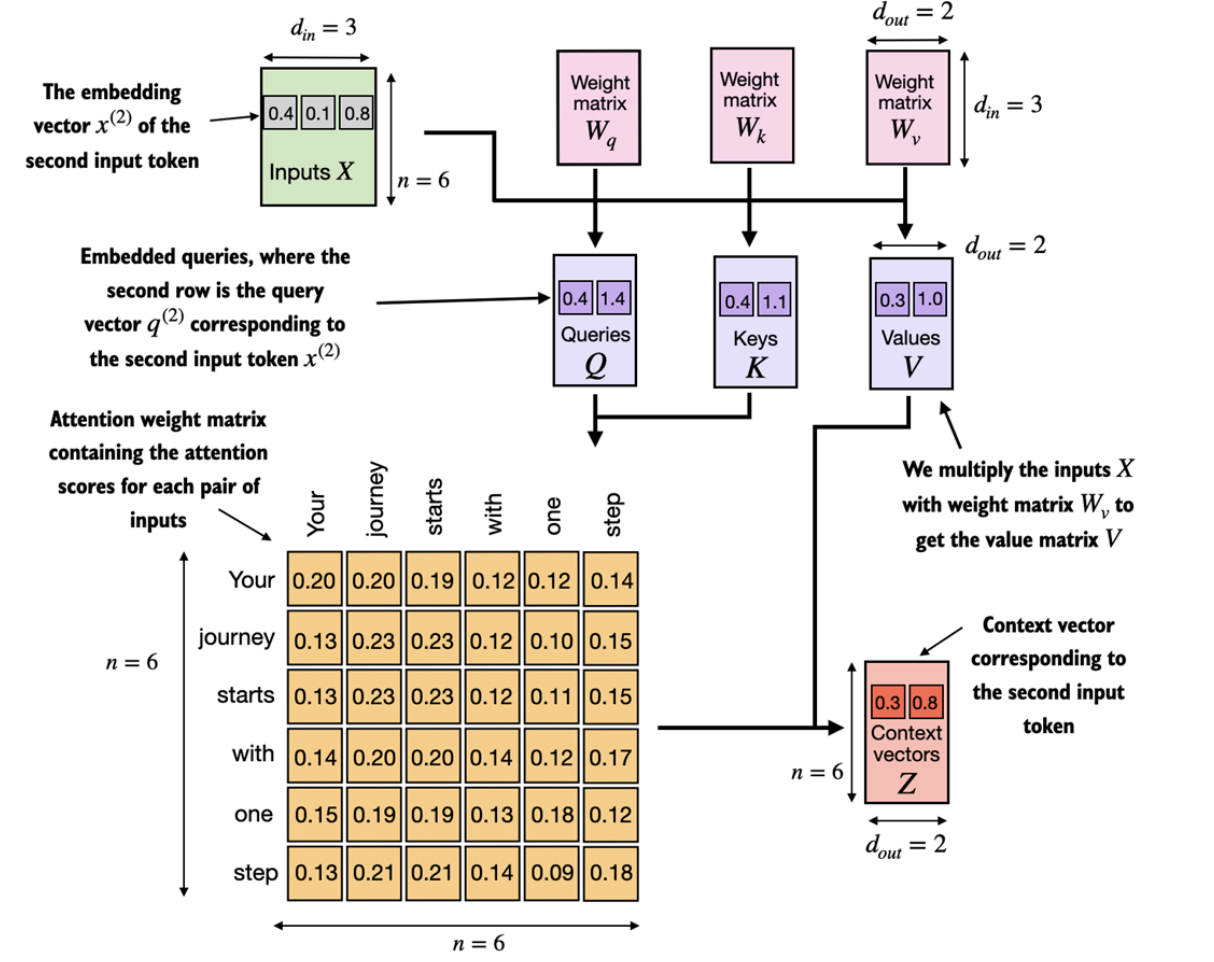

## Summarize the whole process

## Thay vì dùng nn.Parameter ta có thể dùng nn.Linear không có bias
Lí do: [Đâyy](https://gemini.google.com/share/3e8503879abc)

In [18]:
class SelfAttention_v2(nn.Module):
    def __init__(self,d_in,d_out,bias = False):
        super().__init__()
        self.W_q = nn.Linear(torch.rand(d_in,d_out),bias = bias)
        self.W_k = nn.Linear(torch.rand(d_in,d_out),bias = bias)
        self.W_v = nn.Linear(torch.rand(d_in,d_out),bias = bias)
    def forward(self,X):
        queries = X @ self.W_q
        keys = X @ self.W_k
        values = X @ self.W_v
        attn_scores = queries @ keys.T
        attn_weights = torch.softmax(attn_scores / queries.shape[1]**0.5,axis = -1)
        context_vec =  attn_weights @ values
        return context_vec

#3.5 Hiding future words with causal attention

In [19]:
inputs

tensor([[0.4300, 0.1500, 0.8900],
        [0.5500, 0.8700, 0.6600],
        [0.5700, 0.8500, 0.6400],
        [0.2200, 0.5800, 0.3300],
        [0.7700, 0.2500, 0.1000],
        [0.0500, 0.8000, 0.5500]])

In [20]:
context_length = inputs.shape[0]
mask = torch.triu(torch.ones(context_length,context_length),diagonal=1)

masked = attn_scores.masked_fill(mask.bool(),-torch.inf)
masked = torch.softmax(masked / d_out **0.5,dim= -1)
masked

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.4056, 0.5944, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.2566, 0.3741, 0.3693, 0.0000, 0.0000, 0.0000],
        [0.2176, 0.2823, 0.2796, 0.2205, 0.0000, 0.0000],
        [0.1826, 0.2178, 0.2191, 0.1689, 0.2115, 0.0000],
        [0.1473, 0.2033, 0.1996, 0.1500, 0.1160, 0.1839]])

#3.5.2 Masking additional attention weights with dropout

In [21]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.2) #A
example = torch.ones(6, 6) #B
print(example)
print(dropout(example))

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])
tensor([[1.2500, 1.2500, 1.2500, 1.2500, 1.2500, 1.2500],
        [1.2500, 1.2500, 0.0000, 1.2500, 0.0000, 1.2500],
        [1.2500, 1.2500, 1.2500, 1.2500, 1.2500, 1.2500],
        [1.2500, 1.2500, 1.2500, 1.2500, 1.2500, 1.2500],
        [1.2500, 1.2500, 0.0000, 1.2500, 1.2500, 1.2500],
        [1.2500, 1.2500, 1.2500, 1.2500, 1.2500, 1.2500]])


# 3.5.3 Implementing a compact causal attention class
A compact causal attention class

In [22]:
class CausalAttention(nn.Module):
    def __init__(self,d_in,d_out,context_length,dropout,bias = False):
        super().__init__()
        self.d_out = d_out
        self.W_q = nn.Linear(d_in,d_out,bias = bias)
        self.W_k = nn.Linear(d_in,d_out,bias = bias)
        self.W_v = nn.Linear(d_in,d_out,bias = bias)
        self.dropout = nn.Dropout(p = dropout)
        self.register_buffer(
            'mask',
            torch.triu(torch.ones(context_length, context_length),
            diagonal=1)
        )
    def forward(self,X):
        b,num_tokens,d_in = X.shape
        keys = self.W_k(X) # (b,num_tokens,d_out)
        queries = self.W_q(X)
        values = self.W_v(X)

        attn_scores = keys @ values.transpose(1,2) # Chuyển vị chiều thứ 1 và chiều thứ 2(0_index)
        attn_scores.masked_fill(self.mask.bool()[:num_tokens, :num_tokens],-torch.inf)
        attn_weights = torch.softmax(attn_scores / d_in **0.5,dim = -1) # (batch_size,num_tokens,num_tokens)
        attn_weights = self.dropout(attn_weights)
        context_vec = attn_weights @ values
        return context_vec


In [23]:
d_in,d_out = inputs.shape[1],2
context_length = inputs.shape[0]
dropout = 0.3
attention = CausalAttention(d_in,d_out,context_length,dropout)
batch = torch.stack((inputs,inputs),dim = 0)
attention(batch)

tensor([[[-0.4491,  0.5198],
         [-0.4790,  0.5052],
         [-0.2495,  0.2568],
         [-0.4340,  0.5143],
         [-0.6423,  0.7123],
         [-0.5458,  0.6147]],

        [[-0.4660,  0.5019],
         [-0.4685,  0.5266],
         [-0.4191,  0.4385],
         [-0.4251,  0.4666],
         [-0.3616,  0.4314],
         [-0.5458,  0.6147]]], grad_fn=<UnsafeViewBackward0>)

#3.6 Extending single-head attention to multi-head attention

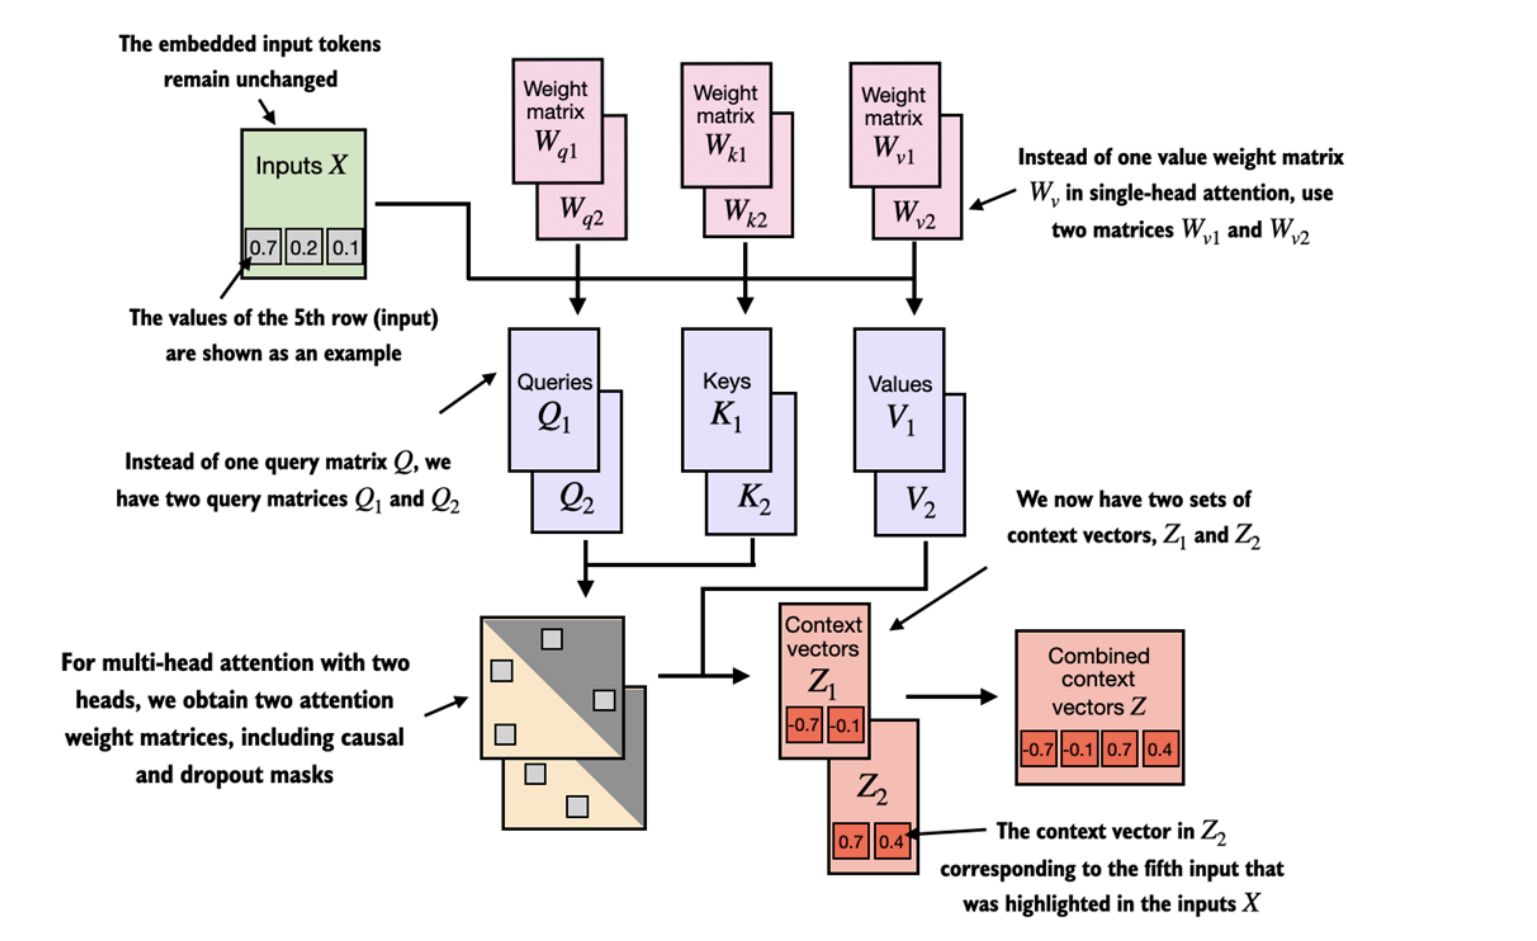

[Tại sao lại nối context vec thay vì cộng nhé](https://gemini.google.com/share/0d8394755b17)

In [24]:
class MultiHeadAttention(nn.Module):
    def __init__(self,d_in,d_out,num_heads,context_length,dropout,bias = False):
        super().__init__()
        self.heads = nn.ModuleList([CausalAttention(d_in,d_out,context_length,dropout,bias) for _ in range(num_heads)])
    def forward(self,X):
        return torch.cat([head(X) for head in self.heads],dim = -1)


In [25]:
num_heads = 2
d_out = 1
Attention = MultiHeadAttention(d_in,d_out,num_heads,context_length,dropout)
Attention(batch)


tensor([[[-0.0850,  0.1821],
         [-0.1353,  0.2724],
         [-0.0734,  0.1870],
         [-0.0771,  0.2316],
         [-0.1052,  0.1431],
         [-0.1050,  0.0562]],

        [[-0.1229,  0.2092],
         [-0.2062,  0.1532],
         [-0.1738,  0.2525],
         [-0.2051,  0.1224],
         [-0.1333,  0.1853],
         [-0.1996,  0.1883]]], grad_fn=<CatBackward0>)

- A Reduce the projection dim to match desired output dim
- B Use a Linear layer to combine head outputs
- C Tensor shape: (b, num_tokens, d_out)
- D We implicitly split the matrix by adding a `num_heads` dimension. Then we unroll last dim: (b,
num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
- E Transpose from shape (b, num_tokens, num_heads, head_dim) to (b, num_heads, num_tokens, head_dim)
- F Compute dot product for each head
- G Mask truncated to the number of tokens
- H Use the mask to fill attention scores
- I Tensor shape: (b, num_tokens, n_heads, head_dim)
- J Combine heads, where self.d_out = self.num_heads * self.head_dim
- K Add an optional linear projection

The key operation is to split the d_out dimension into num_heads and head_dim

In [72]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out,context_length, dropout, num_heads, bias=False):
        super().__init__()
        assert d_out % num_heads == 0
        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dims = int(d_out / num_heads)
        self.W_q = nn.Linear(d_in,d_out,bias = bias)
        self.W_k = nn.Linear(d_in,d_out,bias = bias)
        self.W_v = nn.Linear(d_in,d_out,bias = bias)

        self.dropout = nn.Dropout(p = dropout)
        self.register_buffer(
            'mask',
            torch.tril(torch.ones(context_length,context_length),diagonal=0)
        )
        self.out_proj = nn.Linear(d_out,d_out,bias = bias)
    def forward(self,X):
        batch_size,num_tokens,context_length = X.shape

        queries = self.W_q(X) # (batch_size,num_tokens,d_out)
        keys = self.W_k(X)
        values = self.W_v(X)

        queries = queries.view(batch_size,num_tokens,self.num_heads,self.head_dims) # (batch_size,num_tokens,num_heads,head_dims)
        keys = keys.view(batch_size,num_tokens,self.num_heads,self.head_dims)
        values = values.view(batch_size,num_tokens,self.num_heads,self.head_dims)

        queries = queries.transpose(1,2) # (batch_size,num_heads,num_tokens,head_dims)
        keys = keys.transpose(1,2)
        values = values.transpose(1,2)

        attn_scores = queries @ keys.transpose(2,3) # (batch_size,num_heads,num_tokens,num_tokens)
        attn_scores.masked_fill(self.mask.bool()[:num_tokens,:num_tokens], -torch.inf)
        attn_weights = torch.softmax(attn_scores / queries.shape[-1]**0.5 ,dim = -1)

        context_vec = attn_weights @ values #(batch_size,num_tokens,num_heads,head_dims)
        context_vec = context_vec.transpose(1,2) #(batch_size,num_heads,num_tokens,head_dims)
        context_vec = context_vec.contiguous().view(batch_size,num_tokens,self.d_out)
        context_vec = self.out_proj(context_vec)
        return context_vec



[The reason why we used .contigous()](https://gemini.google.com/share/13b8e81002bc)

[The reason why we must have out_proj layer](https://gemini.google.com/share/57aa941e4fe7)

#EXERCISE 3.3 INITIALIZING GPT-2 SIZE ATTENTION MODULES
Using the MultiHeadAttention class, initialize a multi-head attention module that
has the same number of attention heads as the smallest GPT-2 model (12 attention
heads). Also ensure that you use the respective input and output embedding sizes
similar to GPT-2 (768 dimensions). Note that the smallest GPT-2 model supports a
context length of 1024 tokens

In [73]:
context_length = 1024
num_heads = 12
d_in = 768
d_out = 768
dropout = 0.2
attention = MultiHeadAttention(d_in,d_out,context_length,dropout,num_heads)

In [50]:
batch

tensor([[[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]],

        [[0.4300, 0.1500, 0.8900],
         [0.5500, 0.8700, 0.6600],
         [0.5700, 0.8500, 0.6400],
         [0.2200, 0.5800, 0.3300],
         [0.7700, 0.2500, 0.1000],
         [0.0500, 0.8000, 0.5500]]])

In [61]:
inputs_excercise = torch.rand(2,6,d_in)
inputs_excercise

tensor([[[0.0920, 0.6373, 0.5237,  ..., 0.8563, 0.2916, 0.7142],
         [0.1374, 0.3771, 0.4922,  ..., 0.5086, 0.6772, 0.3385],
         [0.2233, 0.2886, 0.9797,  ..., 0.6613, 0.0452, 0.1191],
         [0.5419, 0.8484, 0.1637,  ..., 0.1084, 0.0638, 0.9900],
         [0.3592, 0.5224, 0.1928,  ..., 0.6513, 0.0526, 0.5185],
         [0.7755, 0.5245, 0.7262,  ..., 0.9082, 0.3566, 0.2740]],

        [[0.3297, 0.0685, 0.5224,  ..., 0.9649, 0.9446, 0.0115],
         [0.2769, 0.0797, 0.1558,  ..., 0.8467, 0.5983, 0.6823],
         [0.6669, 0.8714, 0.7851,  ..., 0.2538, 0.0729, 0.5465],
         [0.4486, 0.5897, 0.8947,  ..., 0.0962, 0.3281, 0.1537],
         [0.8123, 0.3767, 0.2584,  ..., 0.2232, 0.7141, 0.5806],
         [0.7922, 0.1702, 0.5660,  ..., 0.4234, 0.6940, 0.3971]]])

In [75]:
attention(inputs_excercise).shape

torch.Size([2, 6, 768])